<a href="https://colab.research.google.com/github/sota-it/point-source-method/blob/main/HS%26PAS_Point.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--> 多視点情報からの2D IFFTによるHS/PAS波面計算中...
--> ASMによる再生計算中...


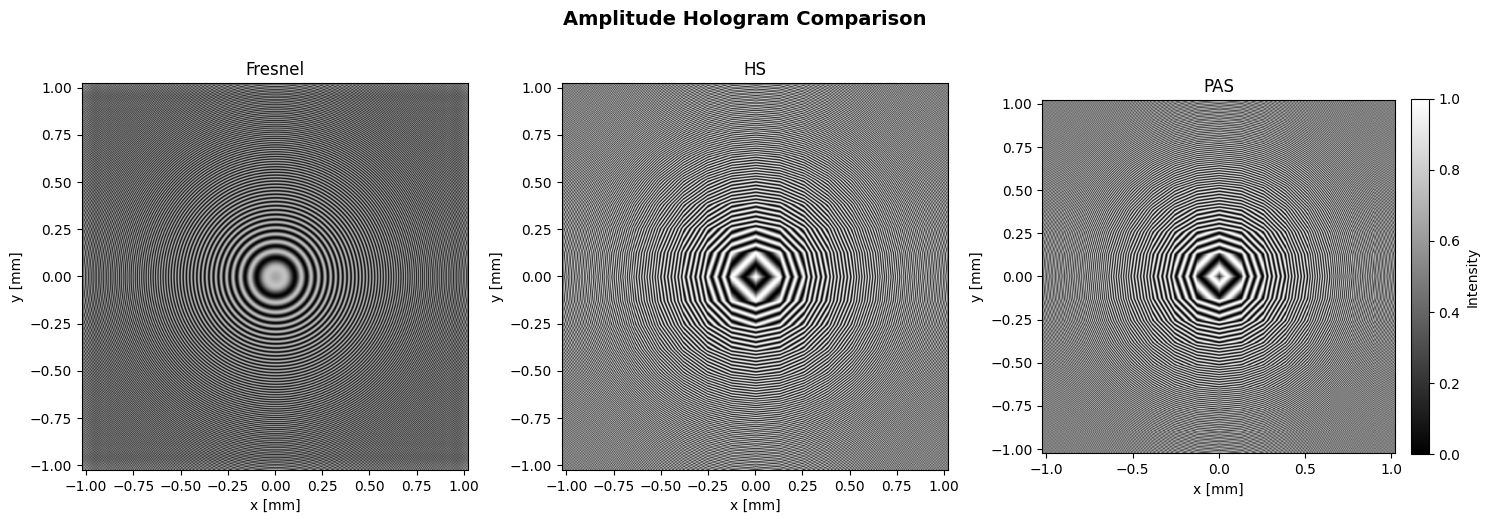

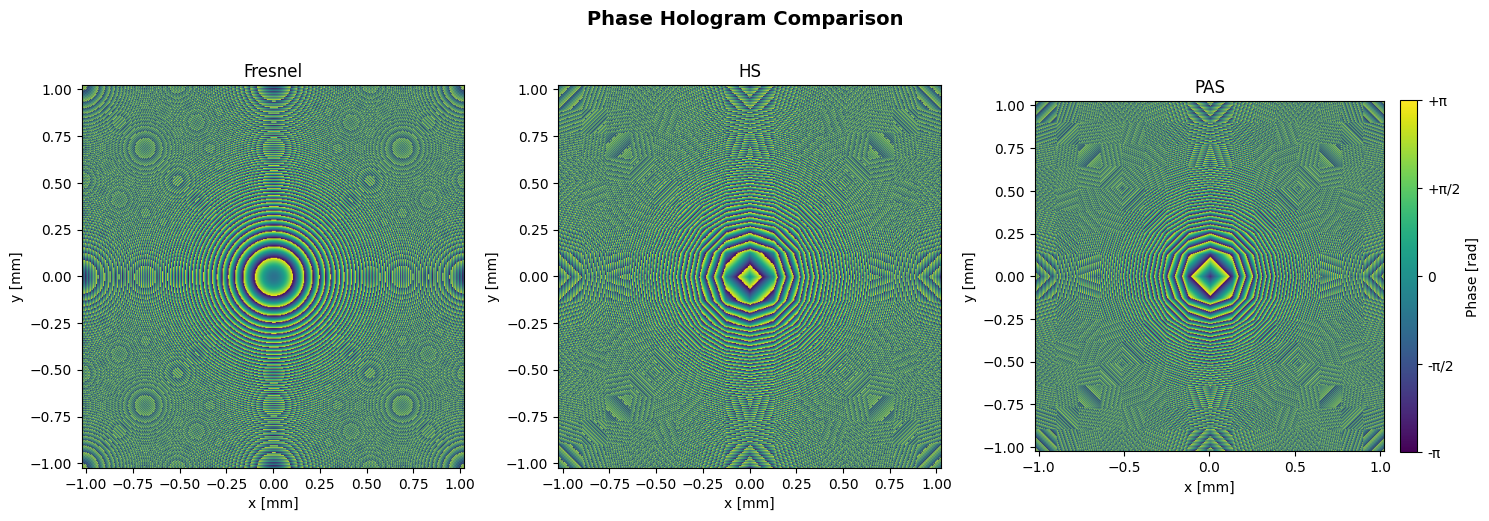

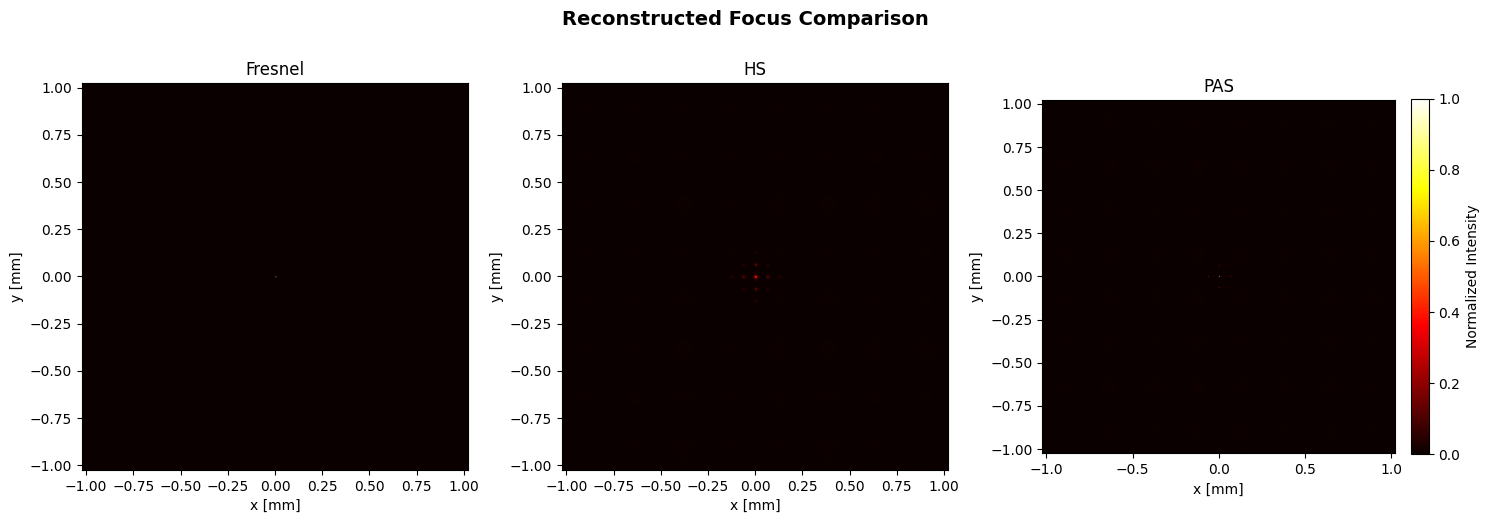

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. パラメータ設定
# =====================================================================
N = 512                 # 解像度 (N x N)
pitch = 4e-6            # ピクセルピッチ [m] (4 um)
wavelength = 633e-9     # 波長 [m]
z_prop = 1.3e-2         # 伝搬(再生)距離 [m] (1.3 cm)
k = 2 * np.pi / wavelength
L = N * pitch           # 計算領域の物理サイズ [m]

hogel_size = 32         # 1ホゲルのピクセル幅
num_hogels = N // hogel_size

# 座標系
dx = pitch
x = np.linspace(-L/2, L/2, N, endpoint=False)
y = np.linspace(-L/2, L/2, N, endpoint=False)
X, Y = np.meshgrid(x, y)

# 空間周波数グリッド
fx = np.fft.fftfreq(N, d=dx)
fy = np.fft.fftfreq(N, d=dx)
FX, FY = np.meshgrid(fx, fy)

# 空間周波数ビン (ホゲル内IFFT用)
fx_bins = np.fft.fftfreq(hogel_size, d=pitch)
fy_bins = np.fft.fftfreq(hogel_size, d=pitch)

# =====================================================================
# 2. 伝搬関数の定義
# =====================================================================
def propagate_asm(u_in, z_dist, wavelength, FX, FY):
    U_in = np.fft.fft2(u_in)
    term = (1/wavelength)**2 - FX**2 - FY**2
    term[term < 0] = 0
    H = np.exp(1j * 2 * np.pi * z_dist * np.sqrt(term))
    U_out = U_in * H
    return np.fft.ifft2(U_out)

# =====================================================================
# 3. 【物体波の生成】 ホログラム面 (z = z_prop) における複素振幅
# =====================================================================

# --- 3-1. 理想的な点光源 (Fresnel) ---
u_object_plane = np.zeros((N, N), dtype=complex)
u_object_plane[N//2, N//2] = 1.0
u_fresnel_prop = propagate_asm(u_object_plane, z_prop, wavelength, FX, FY)

# --- 3-2. HS と PAS ---
u_hs_prop = np.zeros((N, N), dtype=complex)
u_pas_prop = np.zeros((N, N), dtype=complex)

print("--> 多視点情報からの2D IFFTによるHS/PAS波面計算中...")
for hy in range(num_hogels):
    for hx in range(num_hogels):
        y_start, y_end = hy * hogel_size, (hy + 1) * hogel_size
        x_start, x_end = hx * hogel_size, (hx + 1) * hogel_size

        xc = x[x_start + hogel_size // 2]
        yc = y[y_start + hogel_size // 2]

        Rc = np.sqrt(xc**2 + yc**2 + z_prop**2)
        phi_center = k * Rc

        fx_target = xc / (wavelength * Rc)
        fy_target = yc / (wavelength * Rc)

        idx_x = np.argmin(np.abs(fx_bins - fx_target))
        idx_y = np.argmin(np.abs(fy_bins - fy_target))

        amplitude = np.zeros((hogel_size, hogel_size))
        amplitude[idx_y, idx_x] = 1.0

        local_wave = (np.fft.ifft2(amplitude))

        # --- HS ---
        u_hs_prop[y_start:y_end, x_start:x_end] = local_wave

        # --- PAS ---
        u_pas_prop[y_start:y_end, x_start:x_end] = local_wave * np.exp(1j * phi_center)

u_fresnel_prop /= np.max(np.abs(u_fresnel_prop))
u_hs_prop /= np.max(np.abs(u_hs_prop))
u_pas_prop /= np.max(np.abs(u_pas_prop))

# =====================================================================
# 4. 【記録フェーズ】 参照光との干渉による振幅ホログラム (Intensity)
# =====================================================================
u_reference = np.ones((N, N), dtype=complex)

I_fresnel = np.abs(u_fresnel_prop + u_reference)**2
I_hs = np.abs(u_hs_prop + u_reference)**2
I_pas = np.abs(u_pas_prop + u_reference)**2

I_fresnel_norm = I_fresnel / np.max(I_fresnel)
I_hs_norm = I_hs / np.max(I_hs)
I_pas_norm = I_pas / np.max(I_pas)

# =====================================================================
# 5. 【再生フェーズ】 バイアス除去・共役光乗算・逆伝搬 (-z_prop)
# =====================================================================
print("--> ASMによる再生計算中...")

u_rec_plane_fresnel = (I_fresnel - np.mean(I_fresnel)) * np.conj(u_reference)
u_rec_plane_hs = (I_hs - np.mean(I_hs)) * np.conj(u_reference)
u_rec_plane_pas = (I_pas - np.mean(I_pas)) * np.conj(u_reference)

rec_fresnel = np.abs(propagate_asm(u_rec_plane_fresnel, -z_prop, wavelength, FX, FY))**2
rec_hs = np.abs(propagate_asm(u_rec_plane_hs, -z_prop, wavelength, FX, FY))**2
rec_pas = np.abs(propagate_asm(u_rec_plane_pas, -z_prop, wavelength, FX, FY))**2

# =====================================================================
# 6. カテゴリ別まとめ可視化 (各図：1行3列)
# =====================================================================
extent_mm = [-L/2 * 1e3, L/2 * 1e3, -L/2 * 1e3, L/2 * 1e3]
max_I = np.max(rec_fresnel)
method_names = ["Fresnel", "HS", "PAS"]

# 描画用データ構造
plots = [
    {
        "filename": "fig1_amplitude_comparison.png",
        "fig_title": "Amplitude Hologram Comparison",
        "data": [I_fresnel_norm, I_hs_norm, I_pas_norm],
        "cmap": "gray", "vmin": 0, "vmax": 1, "cbar_label": "Intensity"
    },
    {
        "filename": "fig2_phase_comparison.png",
        "fig_title": "Phase Hologram Comparison",
        "data": [np.angle(u_fresnel_prop), np.angle(u_hs_prop), np.angle(u_pas_prop)],
        "cmap": "viridis", "vmin": -np.pi, "vmax": np.pi, "cbar_label": "Phase [rad]"
    },
    {
        "filename": "fig3_focus_comparison.png",
        "fig_title": "Reconstructed Focus Comparison",
        "data": [(rec_fresnel/max_I)**0.5, (rec_hs/max_I)**0.5, (rec_pas/max_I)**0.5],
        "cmap": "hot", "vmin": 0, "vmax": 1, "cbar_label": "Normalized Intensity"
    }
]

# 3枚の独立した図を出力
for p in plots:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(p["fig_title"], fontsize=14, fontweight='bold', y=1.02)

    for i in range(3):
        im = axes[i].imshow(p["data"][i], cmap=p["cmap"],
                            vmin=p["vmin"], vmax=p["vmax"], extent=extent_mm)
        axes[i].set_title(f"{method_names[i]}", fontsize=12)
        axes[i].set_xlabel("x [mm]")
        axes[i].set_ylabel("y [mm]")

        # 右端のグラフだけにカラーバーを付ける（または各グラフにつける場合は ax=axes[i]）
        if i == 2:
            cbar = fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04, label=p["cbar_label"])
            if p["cmap"] == "viridis":
                cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
                cbar.set_ticklabels(['-π', '-π/2', '0', '+π/2', '+π'])

    plt.tight_layout()
    # 画像として保存する場合はコメントアウトを解除
    # plt.savefig(p["filename"], dpi=300, bbox_inches='tight')
    plt.show()